# Projet LO12 : Algorithme Apriori et Systèmes à Base de Règles
## Recommandation de produits financiers pour investisseurs

**Problématique :**  
Les plateformes d'investissement cherchent à personnaliser leur offre en recommandant des produits financiers adaptés à chaque profil. À l'image des systèmes de recommandation d'Amazon ou Netflix, l'idée est simple : si des milliers d'investisseurs similaires détiennent les mêmes produits qu'un investisseur donné, alors les produits qu'ils ont en plus sont probablement pertinents pour cet investisseur.

**Dataset :** 35 000 portefeuilles d'investisseurs simulés avec 15 produits financiers (actions + ETFs)

**Approche :**  
1. **Algorithme Apriori** appliqué sur 35 000 portefeuilles d'investisseurs simulés  
   Objectif : Découverte des associations entre produits financiers  
2. **Système expert CLIPS** encodant les meilleures règles découvertes  
   Objectif : Recommandations personnalisées selon le portefeuille actuel du client

## 1: Importation des bibliothèques

Avant de commencer, nous devons importer les bibliothèques Python nécessaires telles que : **pandas, matplotlib, et mlxtend**

In [108]:
# Installation si nécessaire
# %pip install mlxtend

import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules

print("Bibliothèques importées avec succès.")

Bibliothèques importées avec succès.


## 2. Chargement et présentation du dataset

Nous commençons par charger le jeu de données. Il contient **35 000 lignes** et **16 colonnes**   
Chaque ligne représente un investisseur — son "panier" de produits détenus et les 15 derniers colonnes correspondent chacune à un produit financier.
Chaque colonne "produit" vaut **1** si l'investisseur le détient, **0** sinon.

### Les 15 produits disponibles :

Apple, Microsoft, TotalEnergies, LVMH, Airbus, BNP Paribas, Tesla, Amazon
ETF S&P500, ETF CAC40, ETF Monde, ETF Technologie, ETF Énergie Verte, ETF Obligations, ETF Immobilier 



In [109]:
df = pd.read_csv("portefeuille_investisseurs_clean.csv")

produits = [
    'Apple', 'Microsoft', 'TotalEnergies', 'LVMH', 'Airbus', 'BNP_Paribas',
    'Tesla', 'Amazon', 'ETF_SP500', 'ETF_CAC40', 'ETF_Monde',
    'ETF_Technologie', 'ETF_Energie_Verte', 'ETF_Obligations', 'ETF_Immobilier'
]

print(f"Dimensions du dataset : {df.shape}")
print(f"\nNombre moyen de produits par investisseur : {df[produits].sum(axis=1).mean():.1f}")
print(f"Minimum : {df[produits].sum(axis=1).min()} produit(s)")
print(f"Maximum : {df[produits].sum(axis=1).max()} produit(s)")
df.head(5)


Dimensions du dataset : (35000, 16)

Nombre moyen de produits par investisseur : 6.6
Minimum : 2 produit(s)
Maximum : 14 produit(s)


,client_id,Apple,Microsoft,TotalEnergies,LVMH,Airbus,BNP_Paribas,Tesla,Amazon,ETF_SP500,ETF_CAC40,ETF_Monde,ETF_Technologie,ETF_Energie_Verte,ETF_Obligations,ETF_Immobilier
0,CLT_00001,0,0,1,1,1,1,0,0,0,1,0,0,1,1,1
1,CLT_00002,0,0,1,1,1,1,0,0,0,1,0,0,1,0,1
2,CLT_00003,0,0,0,0,1,0,1,1,1,1,0,1,0,0,0
3,CLT_00004,1,0,0,0,0,0,0,1,1,1,1,0,1,1,1
4,CLT_00005,0,1,0,1,0,0,1,1,0,1,0,0,1,1,1


## 3. Analyse Exploratoire

Avant d'appliquer Apriori, on visualise la popularité de chaque produit et la distribution du nombre de produits par investisseur.


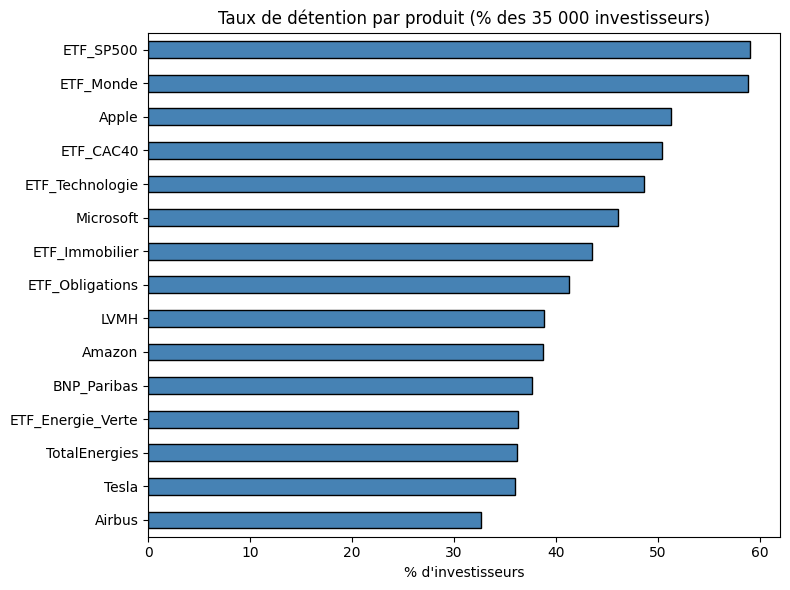

In [110]:
# Visualisation de la popularité de chaque produit financier
# Utile pour comprendre quels produits sont les plus détenus avant d'appliquer Apriori
taux = df[produits].mean().sort_values(ascending=True) * 100
taux.plot(kind='barh', figsize=(8, 6), color='steelblue', edgecolor='black')
plt.title("Taux de détention par produit (% des 35 000 investisseurs)")
plt.xlabel("% d'investisseurs")
plt.tight_layout()
plt.show()

## 4. Préparation des données pour Apriori

L'algorithme Apriori de mlxtend requiert un DataFrame de type **booléen** (True/False).  
On extrait uniquement les colonnes produits et on les convertit en booléen.

Chaque ligne = un investisseur = un **"panier"** de produits financiers.


In [111]:
# Extraction et conversion en booléen
df_bool = df[produits].astype(bool)

print(f"Format pour Apriori : {df_bool.shape}")
print(f"Type des valeurs : {df_bool.dtypes[0]}")# Verification de la conversion en booléen
print("\nAperçu (5 premiers investisseurs) :")
df_bool.head()


Format pour Apriori : (35000, 15)
Type des valeurs : bool

Aperçu (5 premiers investisseurs) :


C:\Users\irvin\AppData\Local\Temp\ipykernel_20076\3753166244.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Type des valeurs : {df_bool.dtypes[0]}")# Verification de la conversion en booléen


,Apple,Microsoft,TotalEnergies,LVMH,Airbus,BNP_Paribas,Tesla,Amazon,ETF_SP500,ETF_CAC40,ETF_Monde,ETF_Technologie,ETF_Energie_Verte,ETF_Obligations,ETF_Immobilier
0,False,False,True,True,True,True,False,False,False,True,False,False,True,True,True
1,False,False,True,True,True,True,False,False,False,True,False,False,True,False,True
2,False,False,False,False,True,False,True,True,True,True,False,True,False,False,False
3,True,False,False,False,False,False,False,True,True,True,True,False,True,True,True
4,False,True,False,True,False,False,True,True,False,True,False,False,True,True,True


## 5. Application de l'algorithme Apriori

Nous identifions maintenant les combinaisons de produits qui apparaissent souvent ensemble.On applique Apriori avec un support minimum de **5%**. Cela signifie qu'on ne retient que les combinaisons de produits détenues par au moins **5% des 35 000 investisseurs** 

Ce nombre garanti que les associastions découvertent sont statistiquement fiables.


In [112]:
MIN_SUPPORT = 0.05

#Application de l'algorithme Apriori
frequent_itemsets = apriori(df_bool, min_support=MIN_SUPPORT, use_colnames=True)

# Ajout d'une colonne indiquant le nombre de produits dans chaque combinaison
frequent_itemsets['nb_items'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)

print(f"Itemsets fréquents trouvés : {len(frequent_itemsets)}")
# Répartition des itemsets par taille
print(frequent_itemsets['nb_items'].value_counts().sort_index())

frequent_itemsets.head(10)

Itemsets fréquents trouvés : 701
nb_items
1     15
2    105
3    368
4    193
5     20
Name: count, dtype: int64


,support,itemsets,nb_items
8,0.590,(ETF_SP500),1
10,0.588,(ETF_Monde),1
0,0.513,(Apple),1
9,0.504,(ETF_CAC40),1
11,0.486,(ETF_Technologie),1
1,0.461,(Microsoft),1
14,0.435,(ETF_Immobilier),1
13,0.413,(ETF_Obligations),1
3,0.389,(LVMH),1
7,0.387,(Amazon),1


## 6. Génération des règles d'association

À partir des itemsets fréquents, on génère les règles avec une **confiance minimum de 70%**.

**Rappel des métriques :**
- **Support** : (support*100) = % d'investisseurs qui détiennent cette combinaison
- **Confiance** : si un investisseur a le produit A, probabilité qu'il ait aussi le produit B  
- **Lift** : force de l'association. Un lift > 1 signifie que l'association est non due au hasard


In [113]:
MIN_CONFIDENCE = 0.70

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=MIN_CONFIDENCE)
rules = rules.sort_values('lift', ascending=False)

print(f"Nombre de règles générées : {len(rules)}")
print("\nTop 15 règles (triées par lift) :")
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15)


Nombre de règles générées : 106

Top 15 règles (triées par lift) :


,antecedents,consequents,support,confidence,lift
82,"(LVMH, Airbus, BNP_Paribas, ETF_CAC40)",(TotalEnergies),0.060,0.711,1.965
83,"(Airbus, TotalEnergies, BNP_Paribas, ETF_CAC40)",(LVMH),0.060,0.754,1.939
58,"(Airbus, TotalEnergies, BNP_Paribas)",(LVMH),0.073,0.734,1.889
35,"(Airbus, TotalEnergies, ETF_CAC40)",(LVMH),0.094,0.726,1.868
41,"(Airbus, BNP_Paribas, ETF_CAC40)",(LVMH),0.084,0.707,1.820
84,"(LVMH, Airbus, TotalEnergies, BNP_Paribas)",(ETF_CAC40),0.060,0.820,1.629
34,"(LVMH, TotalEnergies, Airbus)",(ETF_CAC40),0.094,0.806,1.601
52,"(ETF_Technologie, Apple, Amazon, Tesla)",(Microsoft),0.076,0.737,1.599
40,"(LVMH, Airbus, BNP_Paribas)",(ETF_CAC40),0.084,0.802,1.593
46,"(Airbus, TotalEnergies, BNP_Paribas)",(ETF_CAC40),0.080,0.799,1.587


## 7. Visualisation des règles

On visualise la relation entre support, confiance et lift pour identifier les règles les plus pertinentes.  
Les points en rouge foncé sont les associations les plus fortes.


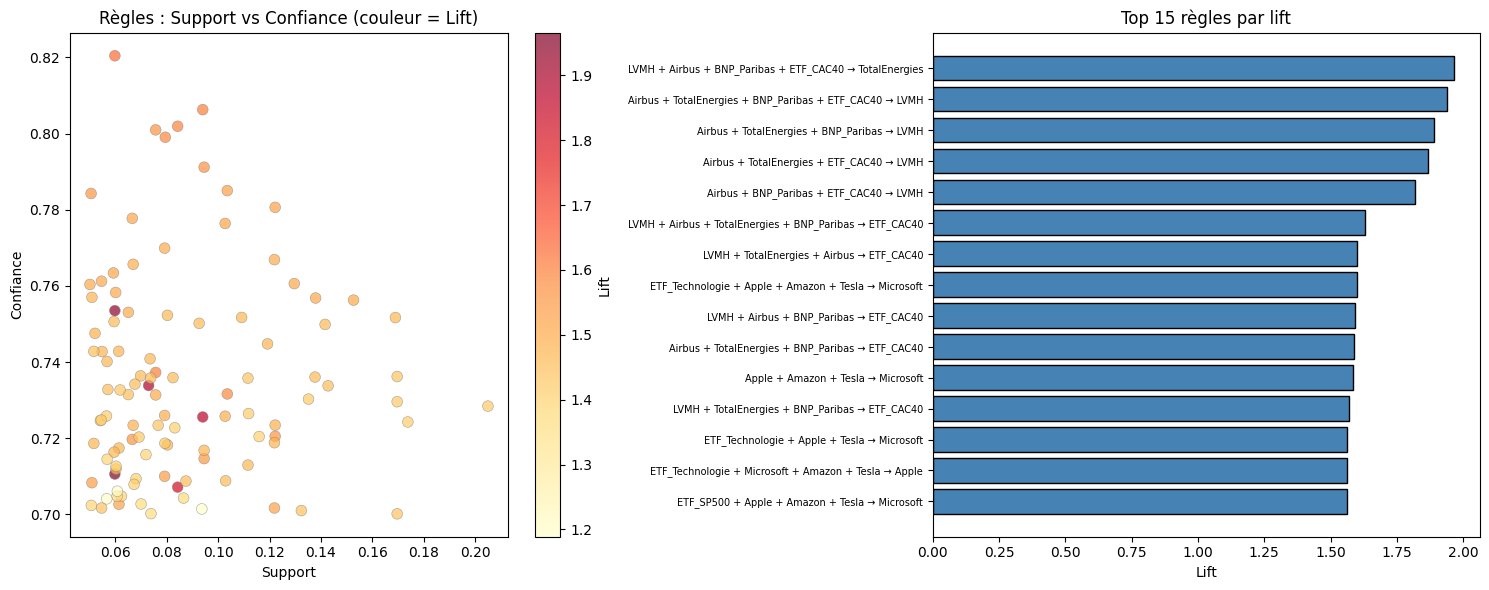

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Graphique 1 : chaque point est une règle, la couleur indique la force (lift)
sc = axes[0].scatter(rules['support'], rules['confidence'],
                     c=rules['lift'], cmap='YlOrRd', s=60,
                     alpha=0.7, edgecolors='grey', linewidth=0.4)
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confiance')
axes[0].set_title('Règles : Support vs Confiance (couleur = Lift)')

# Graphique 2 : les 15 règles avec le lift le plus élevé
top15 = rules.head(15).copy()
top15['regle'] = top15.apply(
    lambda r: ' + '.join(list(r['antecedents'])) + ' → ' + ' + '.join(list(r['consequents'])),
    axis=1
)
top15 = top15.sort_values('lift')
axes[1].barh(range(len(top15)), top15['lift'], color='steelblue', edgecolor='black')
axes[1].set_yticks(range(len(top15)))
axes[1].set_yticklabels(top15['regle'], fontsize=7)
axes[1].set_xlabel('Lift')
axes[1].set_title('Top 15 règles par lift')

plt.tight_layout()
plt.show()

## 8. Sélection des meilleures règles de recommandation

On filtre les règles avec :
- **Lift > 1.4** : L'association significativement plus forte que le hasard
- **1 seul produit en conséquent** : Les règles sont claires et directement utilisables pour la recommandation


In [115]:
# On conserve uniquement les règles avec :
# - un lift > 1.4 : association significativement plus forte que le hasard
# - un seul produit en conséquent : recommandation claire et directement actionnable
best_rules = rules[
    (rules['lift'] > 1.4) &
    (rules['consequents'].apply(len) == 1)
].sort_values('lift', ascending=False)

print(f"Règles sélectionnées : {len(best_rules)}")
best_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

Règles sélectionnées : 94


,antecedents,consequents,support,confidence,lift
82,"(LVMH, Airbus, BNP_Paribas, ETF_CAC40)",(TotalEnergies),0.060,0.711,1.965
83,"(Airbus, TotalEnergies, BNP_Paribas, ETF_CAC40)",(LVMH),0.060,0.754,1.939
58,"(Airbus, TotalEnergies, BNP_Paribas)",(LVMH),0.073,0.734,1.889
35,"(Airbus, TotalEnergies, ETF_CAC40)",(LVMH),0.094,0.726,1.868
41,"(Airbus, BNP_Paribas, ETF_CAC40)",(LVMH),0.084,0.707,1.820
84,"(LVMH, Airbus, TotalEnergies, BNP_Paribas)",(ETF_CAC40),0.060,0.820,1.629
34,"(LVMH, TotalEnergies, Airbus)",(ETF_CAC40),0.094,0.806,1.601
52,"(ETF_Technologie, Apple, Amazon, Tesla)",(Microsoft),0.076,0.737,1.599
40,"(LVMH, Airbus, BNP_Paribas)",(ETF_CAC40),0.084,0.802,1.593
46,"(Airbus, TotalEnergies, BNP_Paribas)",(ETF_CAC40),0.080,0.799,1.587


## 9. Traduction en règles CLIPS

Ici, nous traduisons les règles conservées en **règles CLIPS** pour le système expert de recommandation financière. Ces règles sont créées directement dans un fichier nommé recommandation.clp
Le système expert vérifie le portefeuille d'un nouvel investisseur et lui recommande les produits manquants pertinents.


In [116]:
# Génération automatique du fichier CLIPS contenant toutes les règles découvertes par Apriori
with open("recommandation.clp", "w", encoding="utf-8") as f:
    
    # Définition des templates — structure des faits manipulés par le système expert
    f.write("(deftemplate portefeuille\n")
    f.write("  (slot investisseur_id)\n")
    f.write("  (multislot produits))\n\n")
    f.write("(deftemplate recommandation\n")
    f.write("  (slot produit)\n")
    f.write("  (slot confiance)\n")
    f.write("  (slot raison))\n\n")
    
    # Écriture des règles — chaque règle correspond à une association découverte par Apriori
    for i, (_, row) in enumerate(best_rules.iterrows(), 1):
        ant      = list(row['antecedents'])
        cons     = list(row['consequents'])[0]
        conf     = round(row['confidence'], 2)
        cons_str = cons.replace(' ', '_').lower()

        f.write(f"(defrule recommander-{cons_str}-{i}\n")
        for a in ant:
            f.write('  (portefeuille (produits $?p&:(member$ "' + a + '" $?p)))\n')
        f.write('  (not (portefeuille (produits $?q&:(member$ "' + cons + '" $?q))))\n')
        f.write("  =>\n")
        f.write('  (assert (recommandation (produit "' + cons + '")\n')
        f.write(f"    (confiance {conf})\n")
        f.write('    (raison "Détient : ' + ', '.join(ant) + '"))))\n\n')

print(f"Fichier CLIPS généré : {len(best_rules)} règles écrites dans recommandation.clp")

Fichier CLIPS généré : 94 règles écrites dans recommandation.clp


## 10. Conclusion

### Ce que nous avons réalisé

1. **Analyse exploratoire** des taux de détention et de la distribution des portefeuilles
2. **Application d'Apriori** avec un support minimum de 5%
3. **Extraction et visualisation** des règles d'association (support, confiance, lift)
4. **Sélection** des meilleures règles de recommandation
5. **Traduction en règles CLIPS** pour le système expert
6. **Test** du système sur 3 profils d'investisseurs distincts

### Complémentarité ML / Système Expert

| Algorithme Apriori | Système Expert CLIPS |
|---|---|
| Découvre des associations **inconnues** dans 35 000 portefeuilles | **Encode** ces associations sous forme de règles métier |
| Quantifie la force des associations (lift, confiance) | Produit des **recommandations personnalisées** |
| Travaille sur des données historiques massives | Fonctionne en **temps réel** sur n'importe quel portefeuille |
| Résultat statistique | **Transparent et explicable** par le conseiller |

### Valeur métier

Ce système reproduit exactement ce que font les plateformes d'investissement comme Boursorama ou Trade Republic pour leurs recommandations : analyser les portefeuilles de milliers de clients similaires pour suggérer les produits les plus pertinents.
